# AFM shot-study figures for $N=9$

This notebook only loads existing `.npz` results and draws figures. Each output figure has its own editable code cell. All training-derived data use $N_y=100$ output shots per epoch. The gradient-distribution scans instead use the exact ground-state output expectation, so they have no finite-$N_y$ output sampling.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

_candidates = [
    Path.cwd(),
    Path.cwd() / "QEP_multiple_shot" / "AFM_searching",
]
STUDY_DIR = next(
    path.resolve()
    for path in _candidates
    if (path / "shot_study" / "config.py").exists()
)
WORKSPACE = STUDY_DIR.parents[1]
DATA_DIR = STUDY_DIR / "data" / "shots_2026-09-11"
FIG_DIR = STUDY_DIR / "figures" / "shots_2026-09-11"
PHASE_DIR = WORKSPACE / "AFM_searching" / "data" / "phase"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N = 9
N_Y = 100  # output shots per training epoch
NG_GRID = (10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000)
TRAJECTORY_NG = (10, 100, 1000, 10000)
SHOT_BUDGETS = (5000, 10000, 20000, 50000, 100000)
BUDGET_SEEDS = 5
PARAM_LABELS = (r"$g_\Omega$", r"$g_\Delta$")
COLORS = plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(NG_GRID)))

def load(path):
    return np.load(path, allow_pickle=False)

def save_show(fig, stem):
    for suffix in (".pdf", ".png"):
        kwargs = {"dpi": 180} if suffix == ".png" else {}
        fig.savefig(FIG_DIR / f"{stem}{suffix}", bbox_inches="tight", **kwargs)
    plt.show()

def finish(ax, xlabel, ylabel, title=None, legend=True):
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.grid(alpha=0.22)
    if legend:
        ax.legend(frameon=False, fontsize=8)

def trajectory_files(N_g):
    return sorted(
        path
        for path in (DATA_DIR / "trajectories").glob(
            f"N{N}_init*_Ng{N_g}_seed*.npz"
        )
        if "_smoke" not in path.stem
    )

def load_budget_matrix():
    records = {}
    for N_g in NG_GRID:
        files = sorted(
            path
            for path in (DATA_DIR / "budgets").glob(
                f"N{N}_Ng{N_g}_seed*.npz"
            )
            if "_smoke" not in path.stem
        )
        if len(files) != BUDGET_SEEDS:
            raise RuntimeError(
                f"N={N}, N_g={N_g}: found {len(files)}/{BUDGET_SEEDS} runs"
            )
        records[N_g] = np.stack([
            load(path)["checkpoint_exact_AM2"] for path in files
        ])

    means = []
    for N_g in NG_GRID:
        values = records[N_g]
        counts = np.isfinite(values).sum(axis=0)
        mean = np.full(values.shape[1], np.nan)
        np.divide(
            np.nansum(values, axis=0), counts,
            out=mean, where=counts > 0
        )
        means.append(mean)
    return np.stack(means).T

print("Reading data from:", DATA_DIR)
print("Writing figures to:", FIG_DIR)
print(f"Training data use N_y={N_Y} output shots per epoch")


Reading data from: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/data/shots_2026-09-11
Writing figures to: /Users/qwang/Documents/Programming_Codes/qeps/QEP/QEP_sparse/QEP_multiple_shot/AFM_searching/figures/shots_2026-09-11
Training data use N_y=100 output shots per epoch


## 1. Gradient distributions versus shot count

The dashed black lines are exact gradient expectations evaluated from the exact ground state.


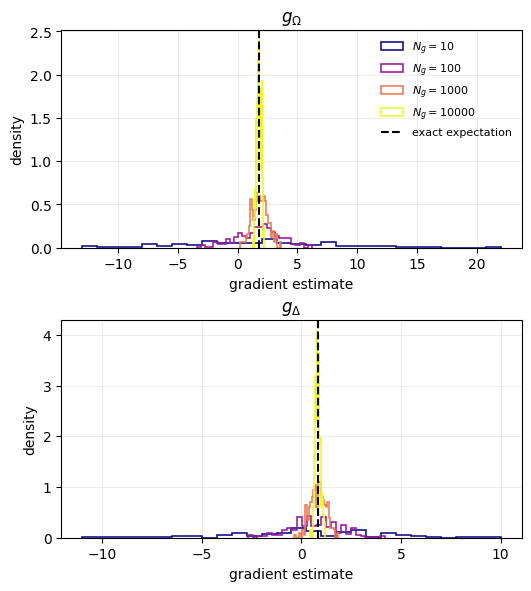

In [2]:
d = load(DATA_DIR / f"gradient_ng_N{N}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
shown = [
    i for i, value in enumerate(values)
    if int(value) in TRAJECTORY_NG
]

fig, axes = plt.subplots(
    2, 1, figsize=(5.2, 5.8), layout="constrained"
)
for p, ax in enumerate(axes):
    for i in shown:
        color = plt.get_cmap("plasma")(
            i / max(1, len(values) - 1)
        )
        ax.hist(
            gradients[i, :, p],
            bins=28,
            density=True,
            histtype="step",
            linewidth=1.15,
            color=color,
            label=rf"$N_g={int(values[i])}$",
        )

    if not np.allclose(
        exact[:, p], exact[0, p], rtol=1e-7, atol=1e-9
    ):
        raise RuntimeError(
            "The exact gradient unexpectedly depends on N_g"
        )
    ax.axvline(
        exact[0, p],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="exact expectation",
    )
    finish(
        ax, "gradient estimate", "density",
        PARAM_LABELS[p], legend=(p == 0)
    )

save_show(fig, f"gradient_distribution_ng_N{N}")


## 2. Gradient distributions versus $\beta$

Each dotted line is the exact ground-state expectation at that $\beta$.


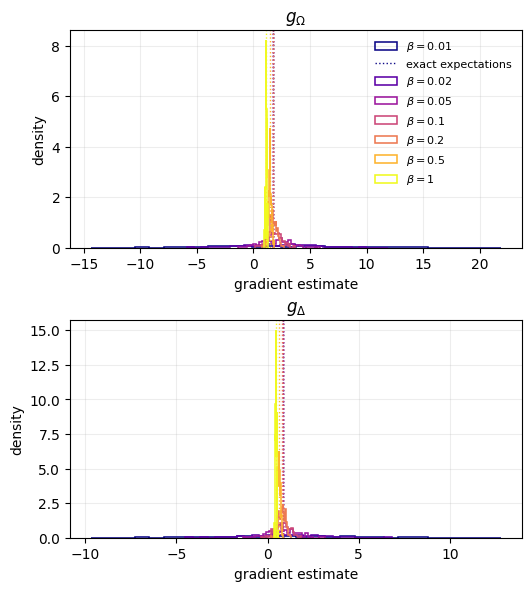

In [3]:
d = load(DATA_DIR / f"gradient_beta_N{N}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]

fig, axes = plt.subplots(
    2, 1, figsize=(5.2, 5.8), layout="constrained"
)
for p, ax in enumerate(axes):
    for i, value in enumerate(values):
        color = plt.get_cmap("plasma")(
            i / max(1, len(values) - 1)
        )
        ax.hist(
            gradients[i, :, p],
            bins=28,
            density=True,
            histtype="step",
            linewidth=1.15,
            color=color,
            label=rf"$\beta={value:g}$",
        )
        ax.axvline(
            exact[i, p],
            color=color,
            linestyle=":",
            linewidth=1.0,
            label="exact expectations" if i == 0 else None,
        )
    finish(
        ax, "gradient estimate", "density",
        PARAM_LABELS[p], legend=(p == 0)
    )

save_show(fig, f"gradient_distribution_beta_N{N}")


## 3. Gradient standard-deviation scaling


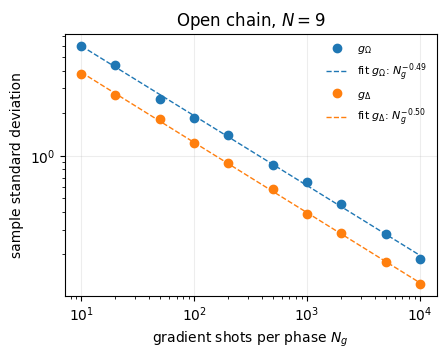

In [4]:
d = load(DATA_DIR / f"gradient_ng_N{N}.npz")
values = d["scan_values"]
std = d["gradients"].std(axis=1, ddof=1)

fig, ax = plt.subplots(figsize=(4.8, 3.4))
for p, label in enumerate(PARAM_LABELS):
    fit = np.polyfit(np.log(values), np.log(std[:, p]), 1)
    fitted_line = np.exp(fit[1]) * values ** fit[0]
    color = ("tab:blue", "tab:orange")[p]
    ax.loglog(values, std[:, p], "o", color=color, label=label)
    ax.loglog(
        values,
        fitted_line,
        "--",
        color=color,
        linewidth=1,
        label=rf"fit {label}: $N_g^{{{fit[0]:.2f}}}$",
    )
finish(
    ax,
    r"gradient shots per phase $N_g$",
    "sample standard deviation",
    rf"Open chain, $N={N}$",
)
save_show(fig, f"gradient_std_scaling_N{N}")


## 4. $\beta$ noise–bias tradeoff, $N_g=1000$

Exact ground-state output; no finite-$N_y$ sampling. RMSE uses the exact gradient at the smallest sampled $\beta$ as its reference.


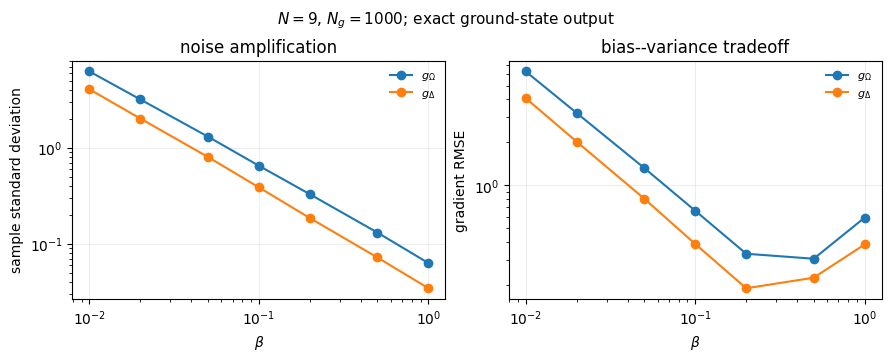

In [5]:
N_g = 1000  # fixed gradient shots per phase
d = load(DATA_DIR / f"gradient_beta_N{N}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
std = gradients.std(axis=1, ddof=1)
reference = exact[0]
rmse = np.sqrt(
    ((gradients - reference[None, None, :]) ** 2).mean(axis=1)
)

fig, axes = plt.subplots(
    1, 2, figsize=(8.8, 3.5), layout="constrained"
)
for p, label in enumerate(PARAM_LABELS):
    axes[0].loglog(values, std[:, p], "o-", label=label)
    axes[1].loglog(values, rmse[:, p], "o-", label=label)
finish(
    axes[0],
    r"$\beta$",
    "sample standard deviation",
    "noise amplification",
)
finish(
    axes[1],
    r"$\beta$",
    "gradient RMSE",
    "bias--variance tradeoff",
)
fig.suptitle(rf"$N={N}$, $N_g={N_g}$; exact ground-state output", fontsize=11)
save_show(fig, f"gradient_beta_tradeoff_N{N}")


## 4a. $\beta$ noise–bias tradeoff, $N_g=10$

256 repetitions per $\beta$, using the exact ground-state output expectation.
RMSE is relative to the exact gradient at the smallest sampled $\beta=0.01$.


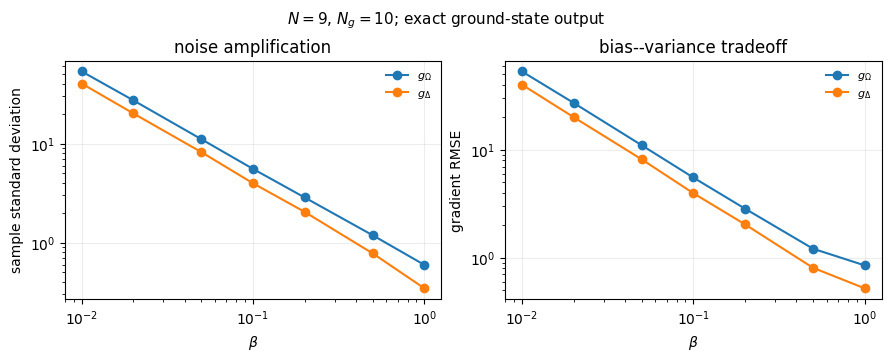

In [6]:
N_g = 10  # fixed gradient shots per phase
d = load(DATA_DIR / f"gradient_beta_N{N}_Ng{N_g}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
std = gradients.std(axis=1, ddof=1)
reference = exact[0]
rmse = np.sqrt(
    ((gradients - reference[None, None, :]) ** 2).mean(axis=1)
)

fig, axes = plt.subplots(
    1, 2, figsize=(8.8, 3.5), layout="constrained"
)
for p, label in enumerate(PARAM_LABELS):
    axes[0].loglog(values, std[:, p], "o-", label=label)
    axes[1].loglog(values, rmse[:, p], "o-", label=label)
finish(
    axes[0],
    r"$\beta$",
    "sample standard deviation",
    "noise amplification",
)
finish(
    axes[1],
    r"$\beta$",
    "gradient RMSE",
    "bias--variance tradeoff",
)
fig.suptitle(rf"$N={N}$, $N_g={N_g}$; exact ground-state output", fontsize=11)
save_show(fig, f"gradient_beta_tradeoff_N{N}_Ng{N_g}")


## 4b. $\beta$ noise–bias tradeoff, $N_g=100$

256 repetitions per $\beta$, using the exact ground-state output expectation.
RMSE is relative to the exact gradient at the smallest sampled $\beta=0.01$.


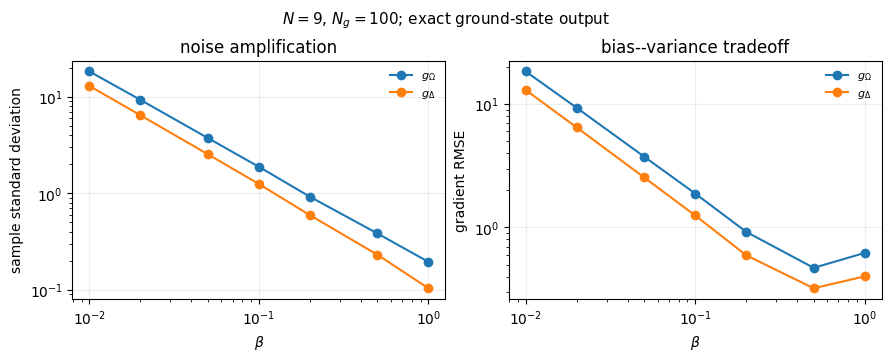

In [7]:
N_g = 100  # fixed gradient shots per phase
d = load(DATA_DIR / f"gradient_beta_N{N}_Ng{N_g}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
std = gradients.std(axis=1, ddof=1)
reference = exact[0]
rmse = np.sqrt(
    ((gradients - reference[None, None, :]) ** 2).mean(axis=1)
)

fig, axes = plt.subplots(
    1, 2, figsize=(8.8, 3.5), layout="constrained"
)
for p, label in enumerate(PARAM_LABELS):
    axes[0].loglog(values, std[:, p], "o-", label=label)
    axes[1].loglog(values, rmse[:, p], "o-", label=label)
finish(
    axes[0],
    r"$\beta$",
    "sample standard deviation",
    "noise amplification",
)
finish(
    axes[1],
    r"$\beta$",
    "gradient RMSE",
    "bias--variance tradeoff",
)
fig.suptitle(rf"$N={N}$, $N_g={N_g}$; exact ground-state output", fontsize=11)
save_show(fig, f"gradient_beta_tradeoff_N{N}_Ng{N_g}")


## 4c. $\beta$ noise–bias tradeoff, $N_g=10000$

256 repetitions per $\beta$, using the exact ground-state output expectation.
RMSE is relative to the exact gradient at the smallest sampled $\beta=0.01$.


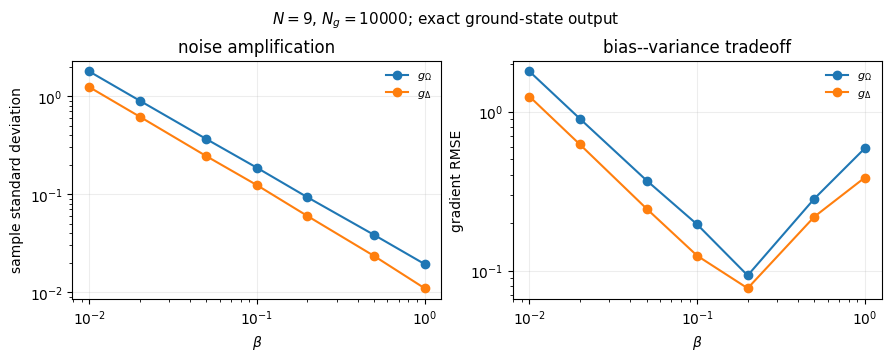

In [8]:
N_g = 10000  # fixed gradient shots per phase
d = load(DATA_DIR / f"gradient_beta_N{N}_Ng{N_g}.npz")
values = d["scan_values"]
gradients = d["gradients"]
exact = d["exact_gradients"]
std = gradients.std(axis=1, ddof=1)
reference = exact[0]
rmse = np.sqrt(
    ((gradients - reference[None, None, :]) ** 2).mean(axis=1)
)

fig, axes = plt.subplots(
    1, 2, figsize=(8.8, 3.5), layout="constrained"
)
for p, label in enumerate(PARAM_LABELS):
    axes[0].loglog(values, std[:, p], "o-", label=label)
    axes[1].loglog(values, rmse[:, p], "o-", label=label)
finish(
    axes[0],
    r"$\beta$",
    "sample standard deviation",
    "noise amplification",
)
finish(
    axes[1],
    r"$\beta$",
    "gradient RMSE",
    "bias--variance tradeoff",
)
fig.suptitle(rf"$N={N}$, $N_g={N_g}$; exact ground-state output", fontsize=11)
save_show(fig, f"gradient_beta_tradeoff_N{N}_Ng{N_g}")


## 5. Phase trajectories for $N_g=10$


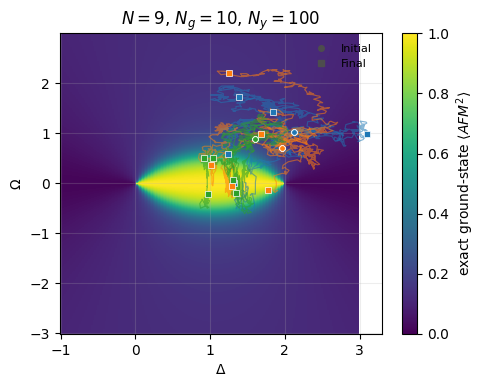

In [9]:
N_g = 10
phase = load(PHASE_DIR / f"phase_chain_N{N}.npz")
files = trajectory_files(N_g)
if len(files) != 15:
    raise RuntimeError(
        f"N={N}, N_g={N_g}: found {len(files)}/15 trajectories"
    )

fig, ax = plt.subplots(figsize=(5.2, 3.9))
mesh = ax.pcolormesh(
    phase["Delta_list"],
    phase["Omega_list"],
    phase["AM2"],
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
    rasterized=True,
)
for path in files:
    d = load(path)
    meta = json.loads(str(d["metadata"]))
    init_id = meta["init_id"]
    ax.plot(
        d["Delta"],
        d["Omega"],
        color=f"C{init_id}",
        alpha=0.55,
        linewidth=0.85,
    )
    ax.plot(
        d["Delta"][0],
        d["Omega"][0],
        "o",
        color=f"C{init_id}",
        markersize=4,
        markeredgecolor="white",
        markeredgewidth=0.5,
        zorder=4,
    )
    ax.plot(
        d["Delta"][-1],
        d["Omega"][-1],
        "s",
        color=f"C{init_id}",
        markersize=4,
        markeredgecolor="white",
        markeredgewidth=0.5,
        zorder=4,
    )
# Neutral legend markers identify the endpoints for every trajectory color.
ax.plot([], [], "o", color="0.3", markersize=4, label="Initial")
ax.plot([], [], "s", color="0.3", markersize=4, label="Final")
fig.colorbar(mesh, ax=ax).set_label(
    r"exact ground-state $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$\Delta$",
    r"$\Omega$",
    rf"$N={N}$, $N_g={N_g}$, $N_y={N_Y}$",
    legend=True,
)
save_show(fig, f"phase_trajectories_N{N}_Ng{N_g}")


## 6. Phase trajectories for $N_g=100$


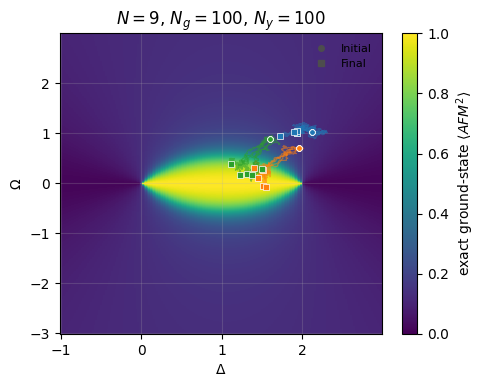

In [10]:
N_g = 100
phase = load(PHASE_DIR / f"phase_chain_N{N}.npz")
files = trajectory_files(N_g)
if len(files) != 15:
    raise RuntimeError(
        f"N={N}, N_g={N_g}: found {len(files)}/15 trajectories"
    )

fig, ax = plt.subplots(figsize=(5.2, 3.9))
mesh = ax.pcolormesh(
    phase["Delta_list"],
    phase["Omega_list"],
    phase["AM2"],
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
    rasterized=True,
)
for path in files:
    d = load(path)
    meta = json.loads(str(d["metadata"]))
    init_id = meta["init_id"]
    ax.plot(
        d["Delta"],
        d["Omega"],
        color=f"C{init_id}",
        alpha=0.55,
        linewidth=0.85,
    )
    ax.plot(
        d["Delta"][0],
        d["Omega"][0],
        "o",
        color=f"C{init_id}",
        markersize=4,
        markeredgecolor="white",
        markeredgewidth=0.5,
        zorder=4,
    )
    ax.plot(
        d["Delta"][-1],
        d["Omega"][-1],
        "s",
        color=f"C{init_id}",
        markersize=4,
        markeredgecolor="white",
        markeredgewidth=0.5,
        zorder=4,
    )
# Neutral legend markers identify the endpoints for every trajectory color.
ax.plot([], [], "o", color="0.3", markersize=4, label="Initial")
ax.plot([], [], "s", color="0.3", markersize=4, label="Final")
fig.colorbar(mesh, ax=ax).set_label(
    r"exact ground-state $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$\Delta$",
    r"$\Omega$",
    rf"$N={N}$, $N_g={N_g}$, $N_y={N_Y}$",
    legend=True,
)
save_show(fig, f"phase_trajectories_N{N}_Ng{N_g}")


## 7. Phase trajectories for $N_g=1000$


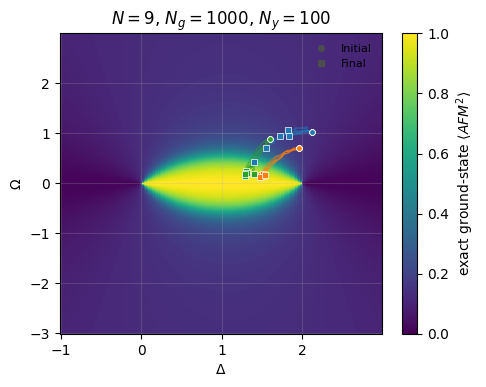

In [11]:
N_g = 1000
phase = load(PHASE_DIR / f"phase_chain_N{N}.npz")
files = trajectory_files(N_g)
if len(files) != 15:
    raise RuntimeError(
        f"N={N}, N_g={N_g}: found {len(files)}/15 trajectories"
    )

fig, ax = plt.subplots(figsize=(5.2, 3.9))
mesh = ax.pcolormesh(
    phase["Delta_list"],
    phase["Omega_list"],
    phase["AM2"],
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
    rasterized=True,
)
for path in files:
    d = load(path)
    meta = json.loads(str(d["metadata"]))
    init_id = meta["init_id"]
    ax.plot(
        d["Delta"],
        d["Omega"],
        color=f"C{init_id}",
        alpha=0.55,
        linewidth=0.85,
    )
    ax.plot(
        d["Delta"][0],
        d["Omega"][0],
        "o",
        color=f"C{init_id}",
        markersize=4,
        markeredgecolor="white",
        markeredgewidth=0.5,
        zorder=4,
    )
    ax.plot(
        d["Delta"][-1],
        d["Omega"][-1],
        "s",
        color=f"C{init_id}",
        markersize=4,
        markeredgecolor="white",
        markeredgewidth=0.5,
        zorder=4,
    )
# Neutral legend markers identify the endpoints for every trajectory color.
ax.plot([], [], "o", color="0.3", markersize=4, label="Initial")
ax.plot([], [], "s", color="0.3", markersize=4, label="Final")
fig.colorbar(mesh, ax=ax).set_label(
    r"exact ground-state $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$\Delta$",
    r"$\Omega$",
    rf"$N={N}$, $N_g={N_g}$, $N_y={N_Y}$",
    legend=True,
)
save_show(fig, f"phase_trajectories_N{N}_Ng{N_g}")


## 8. Phase trajectories for $N_g=10000$


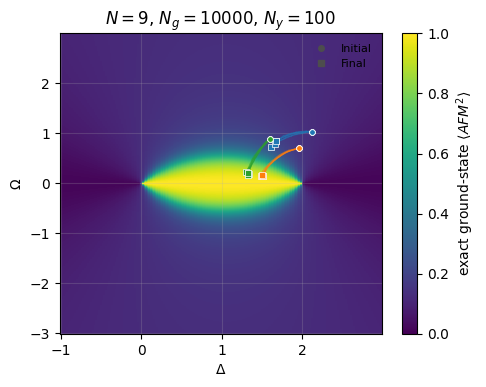

In [12]:
N_g = 10000
phase = load(PHASE_DIR / f"phase_chain_N{N}.npz")
files = trajectory_files(N_g)
if len(files) != 15:
    raise RuntimeError(
        f"N={N}, N_g={N_g}: found {len(files)}/15 trajectories"
    )

fig, ax = plt.subplots(figsize=(5.2, 3.9))
mesh = ax.pcolormesh(
    phase["Delta_list"],
    phase["Omega_list"],
    phase["AM2"],
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1,
    rasterized=True,
)
for path in files:
    d = load(path)
    meta = json.loads(str(d["metadata"]))
    init_id = meta["init_id"]
    ax.plot(
        d["Delta"],
        d["Omega"],
        color=f"C{init_id}",
        alpha=0.55,
        linewidth=0.85,
    )
    ax.plot(
        d["Delta"][0],
        d["Omega"][0],
        "o",
        color=f"C{init_id}",
        markersize=4,
        markeredgecolor="white",
        markeredgewidth=0.5,
        zorder=4,
    )
    ax.plot(
        d["Delta"][-1],
        d["Omega"][-1],
        "s",
        color=f"C{init_id}",
        markersize=4,
        markeredgecolor="white",
        markeredgewidth=0.5,
        zorder=4,
    )
# Neutral legend markers identify the endpoints for every trajectory color.
ax.plot([], [], "o", color="0.3", markersize=4, label="Initial")
ax.plot([], [], "s", color="0.3", markersize=4, label="Final")
fig.colorbar(mesh, ax=ax).set_label(
    r"exact ground-state $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$\Delta$",
    r"$\Omega$",
    rf"$N={N}$, $N_g={N_g}$, $N_y={N_Y}$",
    legend=True,
)
save_show(fig, f"phase_trajectories_N{N}_Ng{N_g}")


## 9. Performance versus training epoch

All curves use **10 initial parameter sets × 5 sampling seeds per set** (50 paths per $N_g$).
The trained parameters are $\Omega,\Delta$, with $V=1$ fixed.
Training lengths are 5,000 / 500 / 200 / 200 epochs for $N_g=10/100/1000/10000$;
$N_y=100$, $\beta=0.1$, and learning rate $0.01$.
Means give equal weight to each start and seed. Shading is **±1 SEM across the 10
initial-point means**, each averaging five seeds; it is not a 95% interval.
These starts are the selected ensemble, not a guarantee about all initial conditions.
No smoothing or new measurement sampling is applied.
The historical 100-step approximate training-state solver is retained.

Uses saved pre-update measurements: point $k+1$ displays the measurement at
$(\Omega_k,\Delta_k)$. Each curve ends at its own completed training length.
Only cached arrays are loaded; no training or diagonalization runs in this notebook.


50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).
Epoch counts for Ng=10/100/1000/10000: 5000/500/200/200; no smoothing.


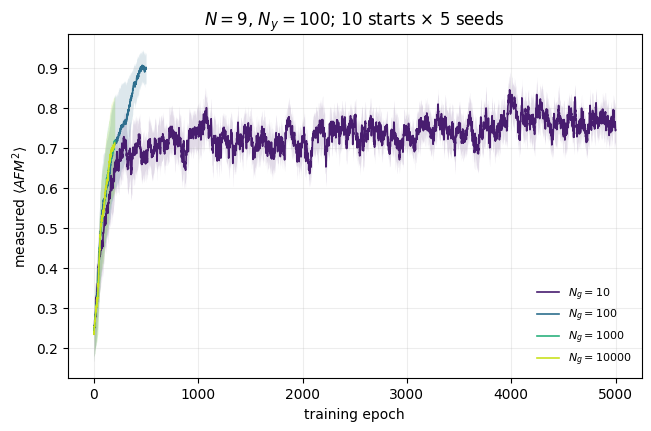

In [13]:
summary_path = DATA_DIR / f"trajectory_overlap_summary_N{N}.npz"
with load(summary_path) as d:
    info = json.loads(str(d["metadata"]))
    assert info["complete"] and info["N"] == N and info["N_y"] == N_Y
    assert info["initial_points"] == 10 and info["seeds_per_point"] == 5
    np.testing.assert_array_equal(d["N_g"], TRAJECTORY_NG)
    fig, ax = plt.subplots(figsize=(6.4, 4.2), layout="constrained")
    for N_g in TRAJECTORY_NG:
        epoch = d[f"epoch_Ng{N_g}"]
        x = epoch
        mean, sem = d[f"mean_Ng{N_g}"], d[f"sem_Ng{N_g}"]
        color = COLORS[NG_GRID.index(N_g)]
        ax.plot(x, mean, color=color, lw=1.2, label=rf"$N_g={N_g}$")
        ax.fill_between(x, mean-sem, mean+sem, color=color, alpha=0.16, linewidth=0)
finish(ax, "training epoch",
       r"measured $\langle AFM^2\rangle$",
       rf"$N={N}$, $N_y={N_Y}$; 10 starts $\times$ 5 seeds")
print("50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).")
print("Epoch counts for Ng=10/100/1000/10000: 5000/500/200/200; no smoothing.")
save_show(fig, f"performance_vs_epoch_N{N}")


## 10. Performance versus cumulative gradient shots

All curves use **10 initial parameter sets × 5 sampling seeds per set** (50 paths per $N_g$).
The trained parameters are $\Omega,\Delta$, with $V=1$ fixed.
Training lengths are 5,000 / 500 / 200 / 200 epochs for $N_g=10/100/1000/10000$;
$N_y=100$, $\beta=0.1$, and learning rate $0.01$.
Means give equal weight to each start and seed. Shading is **±1 SEM across the 10
initial-point means**, each averaging five seeds; it is not a 95% interval.
These starts are the selected ensemble, not a guarantee about all initial conditions.
No smoothing or new measurement sampling is applied.
The historical 100-step approximate training-state solver is retained.

The horizontal axis now counts **physical gradient preparations, $4N_g$ per epoch**:
two noncommuting measurement bases in each of the free and nudged states.
This corrects the older $2N_g$ paired-preparation label; $N_y$ output shots are excluded.
The displayed pre-update measurement at epoch $k+1$ is placed at its allocated
cost $4N_g(k+1)$, including that epoch's gradient allocation.
All four curves share the physical-shot range **40,000–200,000**.
The expanded summary is mandatory; there is no fallback to the old 3-start ensemble.
Figure 11's separate trajectory-observable panel is unchanged by this update.


50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).
Epoch counts for Ng=10/100/1000/10000: 5000/500/200/200; no smoothing.


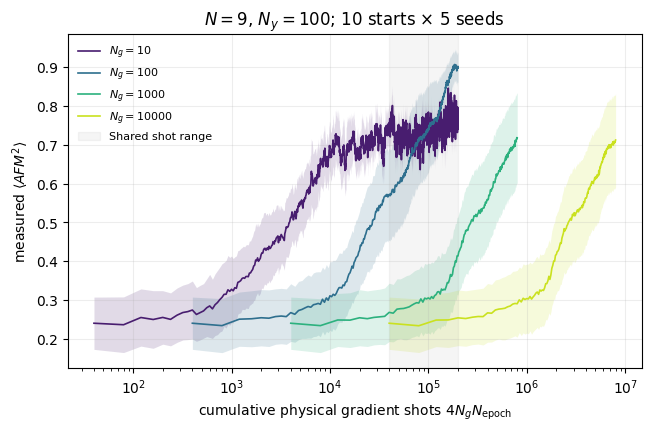

In [14]:
summary_path = DATA_DIR / f"trajectory_overlap_summary_N{N}.npz"
with load(summary_path) as d:
    info = json.loads(str(d["metadata"]))
    assert info["complete"] and info["N"] == N and info["N_y"] == N_Y
    assert info["initial_points"] == 10 and info["seeds_per_point"] == 5
    np.testing.assert_array_equal(d["N_g"], TRAJECTORY_NG)
    fig, ax = plt.subplots(figsize=(6.4, 4.2), layout="constrained")
    for N_g in TRAJECTORY_NG:
        epoch = d[f"epoch_Ng{N_g}"]
        x = 4 * N_g * epoch
        mean, sem = d[f"mean_Ng{N_g}"], d[f"sem_Ng{N_g}"]
        color = COLORS[NG_GRID.index(N_g)]
        ax.plot(x, mean, color=color, lw=1.2, label=rf"$N_g={N_g}$")
        ax.fill_between(x, mean-sem, mean+sem, color=color, alpha=0.16, linewidth=0)
    ax.axvspan(40_000, info["common_physical_gradient_budget"], color="0.5",
               alpha=0.08, label="Shared shot range")
    ax.set_xscale("log")
finish(ax, r"cumulative physical gradient shots $4N_gN_{\rm epoch}$",
       r"measured $\langle AFM^2\rangle$",
       rf"$N={N}$, $N_y={N_Y}$; 10 starts $\times$ 5 seeds")
print("50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).")
print("Epoch counts for Ng=10/100/1000/10000: 5000/500/200/200; no smoothing.")
save_show(fig, f"performance_vs_gradient_shots_N{N}")


## 11. Measured and exact $\langle AFM^2\rangle$ during training

For each $N_g$, average over **all 3 initial parameter points and 5 seeds** (15 runs).
Dashed curves use the saved measurements, with **$N_y=100$ output shots per run per epoch**;
solid curves use the exact free ground-state expectation at each run's actual parameters.
$N_g$ controls gradient shots, not output shots. This is $\langle AFM^2\rangle$, not
$\langle AFM\rangle^2$.

The 200 plotted epochs are **pre-update**: epoch 1 uses the initial parameters;
epoch 200 uses parameters after 199 updates. Both curves use the same parameter points.
Exact expectations were precomputed outside this notebook in
`shot_study/trajectory_expectations.py`; this cell only loads and plots saved data.


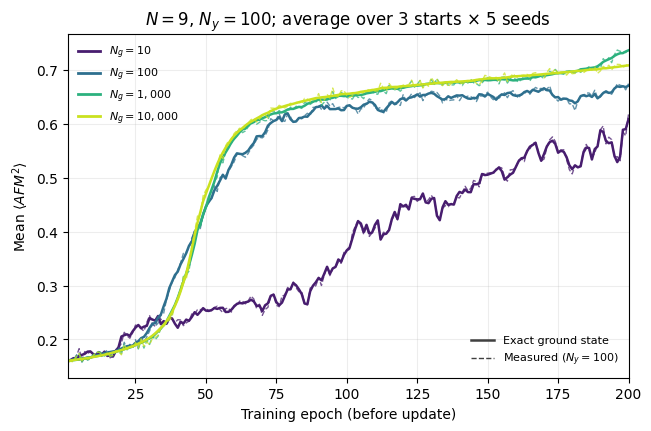

In [15]:
from matplotlib.lines import Line2D

with load(DATA_DIR / f"trajectory_expectations_N{N}.npz") as d:
    metadata = json.loads(str(d["metadata"]))
    assert metadata["N"] == N and metadata["N_y"] == N_Y
    epoch = d["epoch"]
    ng_values = d["N_g"]
    # Axes: N_g, run (3 initial points x 5 seeds), epoch.
    measured_mean = d["measured_AM2"].mean(axis=1)
    exact_mean = d["exact_AM2"].mean(axis=1)

fig, ax = plt.subplots(figsize=(6.4, 4.2), layout="constrained")
ng_handles = []
for i, N_g in enumerate(ng_values):
    color = COLORS[NG_GRID.index(int(N_g))]
    ax.plot(epoch, measured_mean[i], color=color, ls="--", lw=1.0, alpha=0.75)
    ax.plot(epoch, exact_mean[i], color=color, ls="-", lw=1.8)
    ng_handles.append(Line2D([], [], color=color, lw=2, label=rf"$N_g={N_g:,}$"))

finish(
    ax, "Training epoch (before update)", r"Mean $\langle AFM^2\rangle$",
    rf"$N={N}$, $N_y={N_Y}$; average over 3 starts $\times$ 5 seeds",
    legend=False,
)
ax.set_xlim(epoch[0], epoch[-1])
ng_legend = ax.legend(handles=ng_handles, loc="upper left", frameon=False, fontsize=8)
ax.add_artist(ng_legend)
ax.legend(handles=[
    Line2D([], [], color="0.25", ls="-", lw=1.8, label="Exact ground state"),
    Line2D([], [], color="0.25", ls="--", lw=1, label=rf"Measured ($N_y={N_Y}$)"),
], loc="lower right", frameon=False, fontsize=8)
save_show(fig, f"performance_measured_vs_exact_N{N}")


## 11b. Fixed-shot-budget curves: 10 starts × 5 seeds

All curves use **10 initial parameter sets × 5 sampling seeds per set** (50 paths per $N_g$).
The trained parameters are $\Omega,\Delta$, with $V=1$ fixed.
Training lengths are 5,000 / 500 / 200 / 200 epochs for $N_g=10/100/1000/10000$;
$N_y=100$, $\beta=0.1$, and learning rate $0.01$.
Means give equal weight to each start and seed. Shading is **±1 SEM across the 10
initial-point means**, each averaging five seeds; it is not a 95% interval.
These starts are the selected ensemble, not a guarantee about all initial conditions.
No smoothing or new measurement sampling is applied.
The historical 100-step approximate training-state solver is retained.

This plot now uses the **same expanded ensemble as Figures 9 and 10**, at
$N_g=10,100,1000,10000$ only. Intermediate $N_g$ values have not been simulated
for these 10 starts and are not interpolated or borrowed from the single-start study.

For physical gradient-shot caps $S=10,000,20,000,40,000,100,000,200,000$, take
$k=\lfloor S/(4N_g)\rfloor$ completed updates and evaluate **exact ground-state
$\langle AFM^2\rangle$ at $(\Omega_k,\Delta_k)$** using float64 diagonalization,
via the shared, validated `shot_study/exact_solver.py` ground-state solver.
These are the same epoch checkpoints as the former paired budgets $B=S/2$.
Cases with $k=0$ are omitted; no endpoint beyond a completed trajectory is used.
Rounding can leave unused shots. Output shots ($100k$) are not included in $S$.
Exact endpoint evaluation does not correct the approximate training-state solver.

Endpoint calculations and validation live in `shot_study/summarize_overlap.py`,
outside this plotting-only notebook. Unlike the $N=5$ study, there is no separate
single-start / 25-seed fluctuation-check experiment for $N=9$ (that verification
was N5-only); this 10-start / 5-seed ensemble is the only fixed-shot-budget data
available at this system size, and it replaces the smaller original 3-start
`time_budget_N9` curves below.


50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).
S is the physical gradient-shot cap; epochs=floor(S/(4*Ng)); Ny shots excluded.
Only Ng=10,100,1000,10000 were run for this expanded ensemble.
Training retains the historical 100-step solver; endpoints use exact diagonalization.


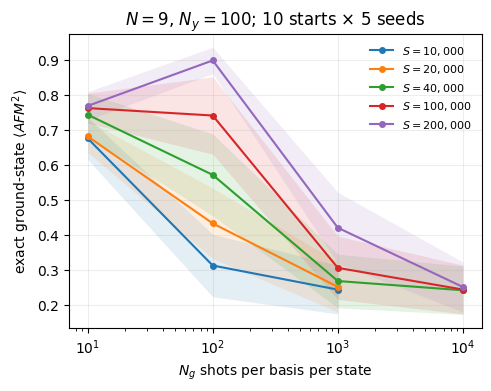

In [16]:
summary_path = DATA_DIR / f"trajectory_overlap_summary_N{N}.npz"
with load(summary_path) as d:
    info = json.loads(str(d["metadata"]))
    assert info["complete"] and info["N"] == N and info["N_y"] == N_Y
    assert info["initial_points"] == 10 and info["seeds_per_point"] == 5
    np.testing.assert_array_equal(d["N_g"], TRAJECTORY_NG)
    budgets = d["physical_budgets"]
    budget_matrix, budget_sem = d["budget_mean"].T, d["budget_sem"].T

fig, ax = plt.subplots(figsize=(4.8, 3.8), layout="constrained")
for i, budget in enumerate(budgets):
    valid = np.isfinite(budget_matrix[i])
    x = np.asarray(TRAJECTORY_NG)[valid]
    mean, sem = budget_matrix[i, valid], budget_sem[i, valid]
    line, = ax.plot(x, mean, "o-", lw=1.5, ms=4, label=rf"$S={budget:,}$")
    ax.fill_between(x, mean-sem, mean+sem, color=line.get_color(),
                    alpha=0.12, linewidth=0)
ax.set_xscale("log")
finish(ax, r"$N_g$ shots per basis per state",
       r"exact ground-state $\langle AFM^2\rangle$",
       rf"$N={N}$, $N_y={N_Y}$; 10 starts $\times$ 5 seeds")
print("50 paths per Ng; mean +/- SEM across 10 initial-point means (5 seeds each).")
print("S is the physical gradient-shot cap; epochs=floor(S/(4*Ng)); Ny shots excluded.")
print("Only Ng=10,100,1000,10000 were run for this expanded ensemble.")
print("Training retains the historical 100-step solver; endpoints use exact diagonalization.")
for suffix in (".pdf", ".png"):
    kwargs = {"dpi": 180} if suffix == ".png" else {}
    fig.savefig(FIG_DIR / f"time_budget_N{N}_10starts_5seeds{suffix}",
                bbox_inches="tight", **kwargs)
save_show(fig, f"time_budget_N{N}")


## 12. Fixed-shot-budget heatmap


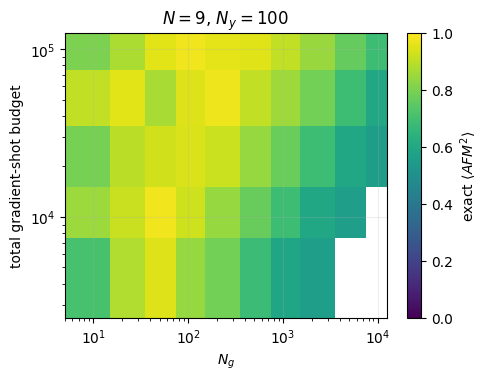

In [17]:
budget_matrix = load_budget_matrix()

fig, ax = plt.subplots(figsize=(5.2, 3.7))
masked = np.ma.masked_invalid(budget_matrix)
mesh = ax.pcolormesh(
    np.asarray(NG_GRID),
    np.asarray(SHOT_BUDGETS),
    masked,
    shading="nearest",
    cmap="viridis",
    vmin=0,
    vmax=1,
)
ax.set_xscale("log")
ax.set_yscale("log")
fig.colorbar(
    mesh, ax=ax, label=r"exact $\langle AFM^2\rangle$"
)
finish(
    ax,
    r"$N_g$",
    "total gradient-shot budget",
    rf"$N={N}$, $N_y={N_Y}$",
    legend=False,
)
save_show(fig, f"time_budget_heat_N{N}")


## 13. Gradient moments during training


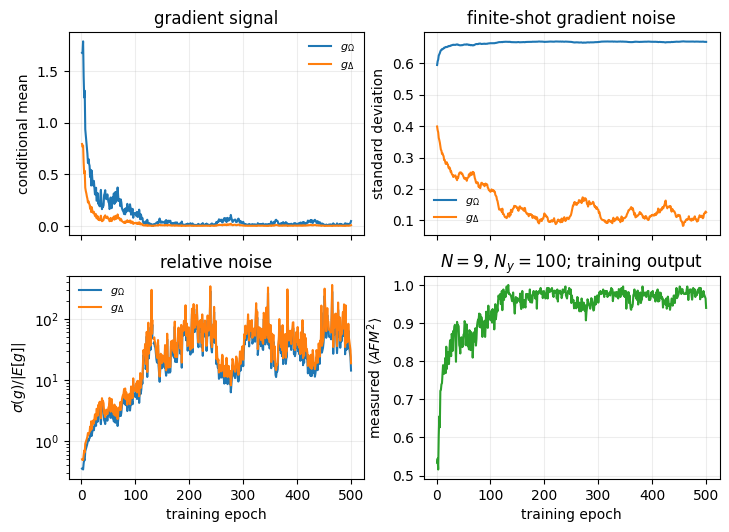

In [18]:
d = load(
    DATA_DIR / f"gradient_during_training_N{N}.npz"
)
mean = d["expected_gradient"]
std = np.sqrt(np.maximum(d["gradient_variance"], 0))
ratio = np.divide(
    std,
    np.abs(mean),
    out=np.full_like(std, np.nan),
    where=np.abs(mean) > 1e-12,
)
epoch = np.arange(1, len(mean) + 1)

fig, axes = plt.subplots(
    2, 2, figsize=(8.4, 5.8), sharex=True
)
for p, label in enumerate(PARAM_LABELS):
    axes[0, 0].plot(epoch, mean[:, p], label=label)
    axes[0, 1].plot(epoch, std[:, p], label=label)
    axes[1, 0].semilogy(epoch, ratio[:, p], label=label)
axes[1, 1].plot(epoch, d["measured_AM2"], color="C2")
finish(
    axes[0, 0], "", "conditional mean", "gradient signal"
)
finish(
    axes[0, 1],
    "",
    "standard deviation",
    "finite-shot gradient noise",
)
finish(
    axes[1, 0],
    "training epoch",
    r"$\sigma(g)/|E[g]|$",
    "relative noise",
)
finish(
    axes[1, 1],
    "training epoch",
    r"measured $\langle AFM^2\rangle$",
    rf"$N={N}$, $N_y={N_Y}$; training output",
    legend=False,
)
save_show(fig, f"gradient_moments_during_training_N{N}")


## 14. Expanded-seed check of the budget-50,000 curve

This cell reads the saved 25-seed summary; it does not rerun any training.


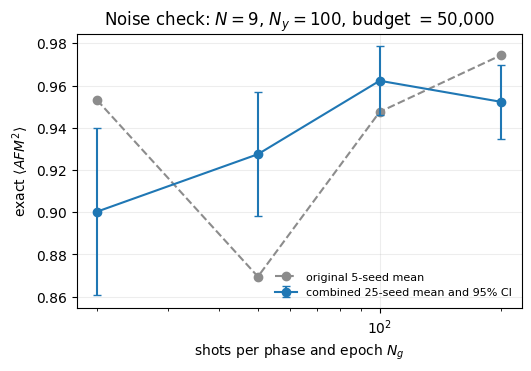

In [19]:
noise_summary = json.loads(
    (DATA_DIR / "budget_noise_check_summary.json").read_text()
)
x = np.array([20, 50, 100, 200])
original = noise_summary["original_5_seeds"]
combined = noise_summary["combined_25_seeds"]
old_mean = np.array([original[str(N_g)]["mean"] for N_g in x])
mean = np.array([combined[str(N_g)]["mean"] for N_g in x])
low = np.array([combined[str(N_g)]["ci95"][0] for N_g in x])
high = np.array([combined[str(N_g)]["ci95"][1] for N_g in x])

fig, ax = plt.subplots(figsize=(5.2, 3.6), layout="constrained")
ax.plot(
    x, old_mean, "o--", color="0.55",
    label="original 5-seed mean",
)
ax.errorbar(
    x, mean, yerr=np.vstack((mean - low, high - mean)),
    fmt="o-", capsize=3,
    label="combined 25-seed mean and 95% CI",
)
ax.set_xscale("log")
finish(
    ax,
    r"shots per phase and epoch $N_g$",
    r"exact $\langle AFM^2\rangle$",
    rf"Noise check: $N={N}$, $N_y={N_Y}$, budget $=50{{,}}000$",
)
save_show(fig, "time_budget_N9_noise_check")
